<a href="https://colab.research.google.com/github/jjnoll/jjnoll/blob/main/Predicting_Accidents_Based_on_road_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Package imports & Helper Functions

In [ ]:
import os
import time
from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb

from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
def prediction_scatterplot(title, y_true, y_pred):
    plt.scatter(y_true, y_pred, alpha=0.5, marker='.')
    plt.title(f'{title} Actual vs. Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--')
    plt.tight_layout()
    plt.show()

## Data loading

In [ ]:
# Uploading kaggle.json only if not already present
if not os.path.exists('kaggle.json'):
    print('Upload your Kaggle API key to this virtual environment.')
    files.upload()
else:
    print('kaggle.json already exists. Skipping upload.')

# Create the directories to store the JSON file and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the competition data
!kaggle competitions download -c playground-series-s5e10

# Unzip the downloaded data if the main data file doesn't exist
if not os.path.exists('train.csv'):
    print('Unzipping data...')
    !unzip -n playground-series-s5e10.zip
else:
    print('Competition files already present. Skipping unzip.')

kaggle.json already exists. Skipping upload.
playground-series-s5e10.zip: Skipping, found more recently modified local copy (use --force to force download)
Competition files already present. Skipping unzip.


In [ ]:
# Read and preview data
df = pd.read_csv('train.csv')

df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


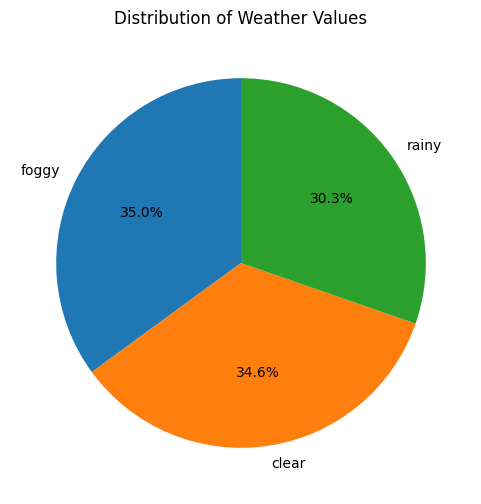

In [ ]:
counts = df['weather'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Weather Values")
plt.show()


## Data Preperation & Feature Engineering

In [ ]:
# One-hot encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns to be encoded:")
print(categorical_cols)

objects = []
for c in df.columns:
    if str(df[c].dtype) == 'object':
        objects.append(c)
X_ = df.drop(objects, axis = 1).astype('float64')

dummies = pd.get_dummies(df[objects], drop_first=True, dtype=int)
df_processed = pd.concat([X_, dummies], axis = 1)
df_processed.drop('id', axis = 1, inplace = True)

Categorical columns to be encoded:
Index(['road_type', 'lighting', 'weather', 'time_of_day'], dtype='object')


In [ ]:
# Add feature of interaction between speed limit and curvature
df_processed['curve_danger'] = df['speed_limit'] * df['curvature']

# Add feature to represent low light in rural areas (night time with no street lights)
df_processed['low_light'] = df_processed['road_type_rural'] * (df_processed['lighting_dim'] + df_processed['lighting_night'])

# Add feature for low visibility
df_processed['low_visibility'] = (df_processed['weather_foggy'] + df_processed['weather_rainy']) * (df_processed['lighting_dim'] + df_processed['lighting_night'])

In [ ]:
# Scale continuous columns

cols_to_scale = ['num_lanes', 'speed_limit', 'curve_danger']

scaler = StandardScaler()
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

df_processed.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,curve_danger,low_light,low_visibility
0,-0.438680,0.06,-0.703840,0.0,1.0,0.0,1.0,1.0,0.13,0,1,0,0,0,1,0,0,-1.331952,0,0
1,1.346344,0.99,-0.703840,1.0,0.0,1.0,1.0,0.0,0.35,0,1,0,0,0,0,1,0,0.785795,0,0
2,1.346344,0.63,1.512963,0.0,1.0,1.0,0.0,2.0,0.30,1,0,1,0,0,0,0,1,1.400625,1,0
3,1.346344,0.07,-0.703840,1.0,1.0,0.0,0.0,1.0,0.21,0,0,1,0,0,1,0,1,-1.309181,0,1
4,-1.331192,0.58,0.879591,0.0,0.0,1.0,0.0,1.0,0.56,1,0,0,0,1,0,1,0,0.795555,0,0


In [ ]:
# Split data to training and testing sets

y = df_processed['accident_risk']
X = df_processed.drop('accident_risk', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(df.shape)

(414203, 19)
(103551, 19)
(517754, 14)


## EDA

<Axes: >

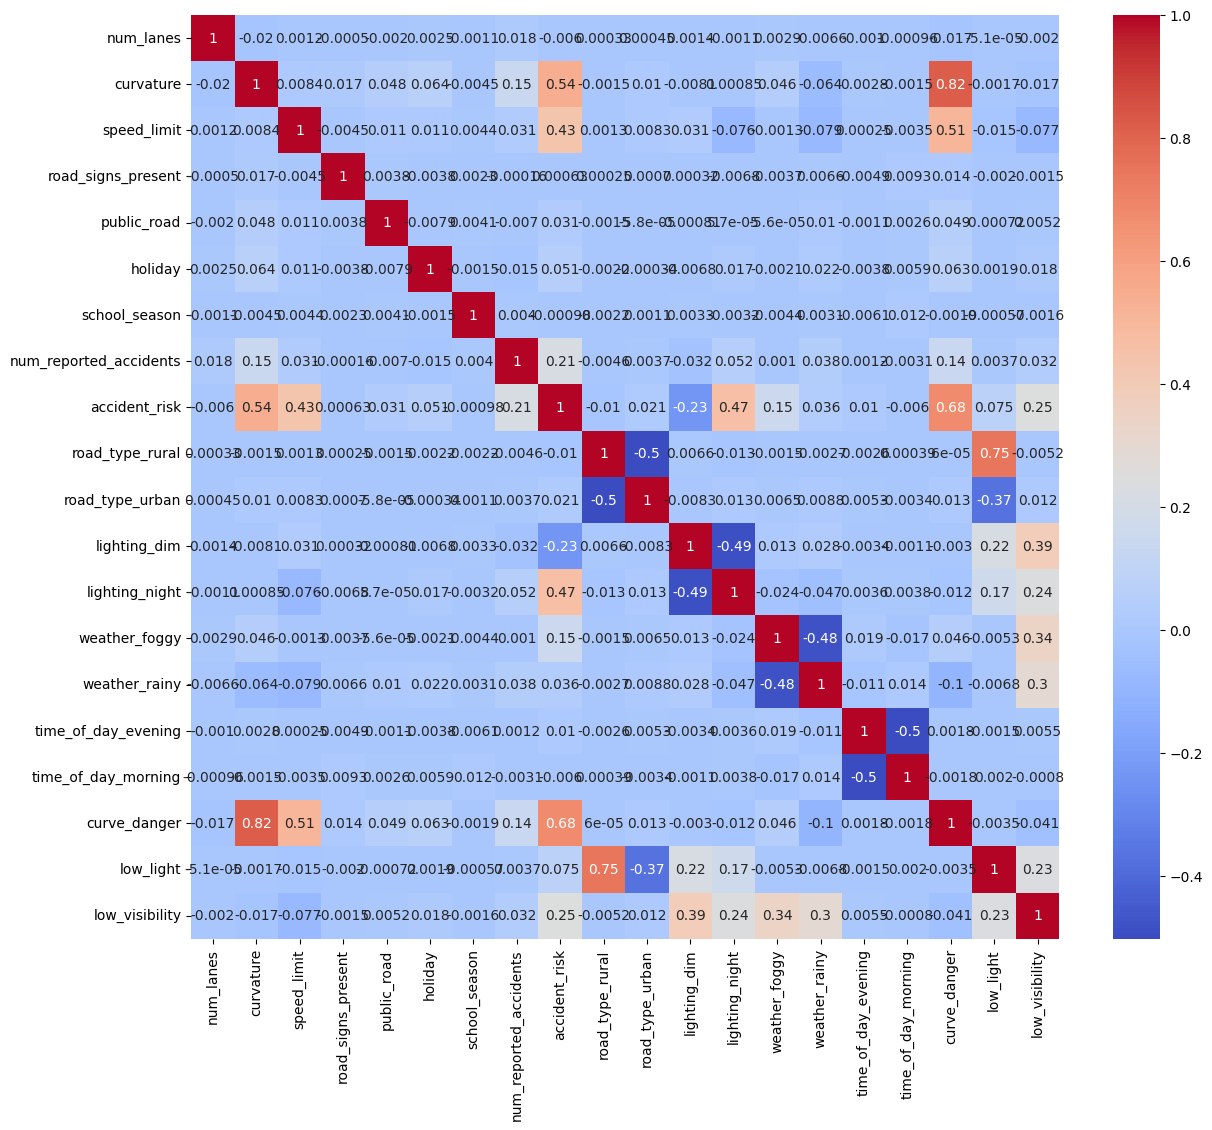

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(df_processed.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')

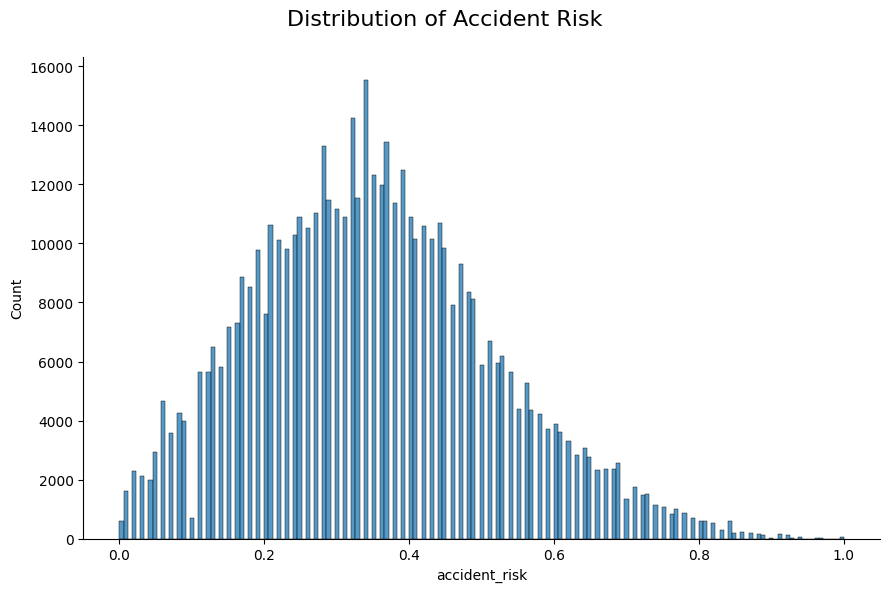

In [ ]:
# output distribution
g = sns.displot(df['accident_risk'], height=6, aspect=1.5);
g.fig.suptitle("Distribution of Accident Risk", fontsize=16)

# Adjust layout so the title doesn't overlap the plot
g.fig.subplots_adjust(top=0.9)


## Baseline regression

In [ ]:
ols = LinearRegression()

ols_results = cross_validate(ols, X, y, cv=5, scoring=['neg_root_mean_squared_error', 'r2'])

neg_rmse_scores_ols = ols_results['test_neg_root_mean_squared_error']
r2_scores_ols = ols_results['test_r2']

rmse_scores_ols = -neg_rmse_scores_ols

print(f"RMSE scores for each of the 5 folds: {rmse_scores_ols}")
print(f"Average RMSE across all folds: {rmse_scores_ols.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores_ols.std():.4f}")

print(f"R2 per fold: {r2_scores_ols}")
print(f"Average R2:      {r2_scores_ols.mean():.4f}")

RMSE scores for each of the 5 folds: [0.07371319 0.07330657 0.07363401 0.07342085 0.07329663]
Average RMSE across all folds: 0.0735
Standard deviation of RMSE: 0.0002
R2 per fold: [0.80381683 0.80555329 0.80479532 0.80499525 0.80618316]
Average R2:      0.8051


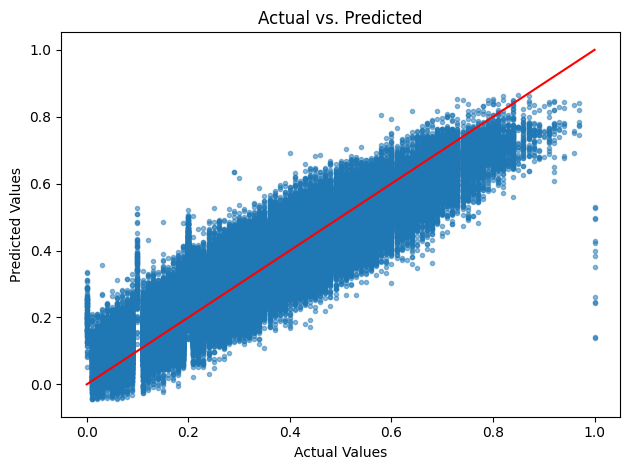

In [ ]:
predictons_ols = ols.fit(X_train, y_train).predict(X_test)

prediction_scatterplot(y_test, predictons_ols)

## Random Forest

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best RMSE (CV): 0.0563


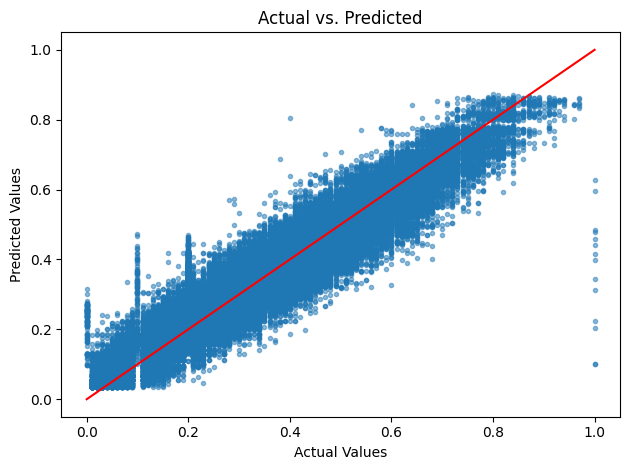

In [ ]:
#### TAKES 42 MINUTES TO RUN ON T4 HIGH RAM

# 1. Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],      # Min samples required to split a node
    'min_samples_leaf': [1, 2, 4]         # Min samples required at each leaf node
}

# 2. Initialize the base model
# We typically leave hyperparameters out here since they will be passed by the grid
rf_base = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,           # Only try 20 random combinations (instead of 108)
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# This will run ~5x faster than GridSearchCV
random_search.fit(X_train, y_train)



# # 3. Instantiate GridSearchCV
# grid_search = GridSearchCV(
#     estimator=rf_base,
#     param_grid=param_grid,
#     cv=3,                                 # 3-fold cross-validation
#     scoring='neg_root_mean_squared_error',# Metric to optimize (negative RMSE)
#     n_jobs=-1,                            # Use all available CPU cores
#     verbose=1                             # Print progress messages
# )

# # 4. Fit the grid search to the data
# print("Starting Grid Search...")
# grid_search.fit(X_train, y_train)

# 5. Display the best results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best RMSE (CV): {-random_search.best_score_:.4f}")

# 6. (Optional) Replace your old model with the best one found
best_rf_model = random_search.best_estimator_

# Predict on test set with the tuned model
tuned_predictions = best_rf_model.predict(X_test)
prediction_scatterplot('Random Forest', y_test, tuned_predictions)

In [ ]:
# 1. Initialize the Random Forest
rf = RandomForestRegressor(n_estimators=100,
                           random_state=42,
                           n_jobs=-1,
                           min_samples_split=5,
                           min_samples_leaf=1,
                           max_depth=10)

# 2. Calculate Cross-Validation Scores
results = cross_validate(rf, X, y, cv=5, scoring=['neg_root_mean_squared_error', 'r2'])

neg_rmse_scores_rf = results['test_neg_root_mean_squared_error']
r2_scores_rf = results['test_r2']

# 3. Flip the sign to make them positive
rmse_scores_rf = -neg_rmse_scores_rf

print(f"Random Forest RMSE scores: {rmse_scores_rf}")
print(f"Average RF RMSE: {rmse_scores_rf.mean():.4f}")
print(f"Standard deviation: {rmse_scores_rf.std():.4f}")


print(f"R2 Scores per fold: {r2_scores_rf}")
print(f"Average R2:      {r2_scores_rf.mean():.4f}")

Random Forest RMSE scores: [0.05658364 0.05592006 0.05645678 0.05635501 0.05607226]
Average RF RMSE: 0.0563
Standard deviation: 0.0002
R2 Scores per fold: [0.88440126 0.88685115 0.88524659 0.88511287 0.88657217]
Average R2:      0.8856


In [ ]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=5, n_jobs=-1,
                      random_state=42)

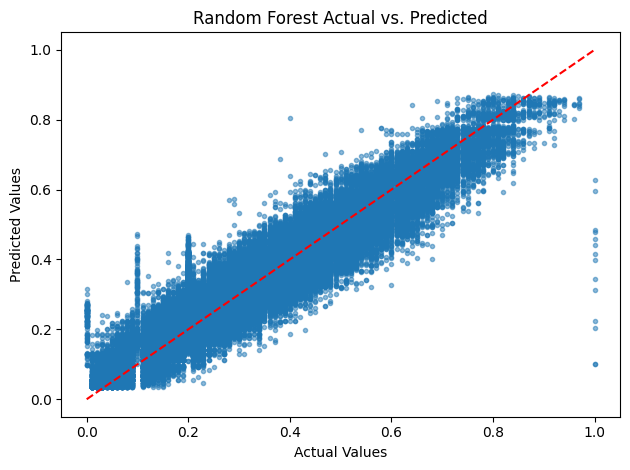

In [ ]:
predictions_rf = rf.predict(X_test)

prediction_scatterplot('Random Forest', y_test, predictions_rf)

## Gradient Boosting

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
boost = GradientBoostingRegressor(random_state=42)
boost.fit(X_train, y_train)

y_train_pred = boost.predict(X_train)
y_test_pred  = boost.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

rmse_train = mean_squared_error(y_train, y_train_pred)#, squared=False)
rmse_test  = mean_squared_error(y_test, y_test_pred)#, squared=False)


print(f"Train R²: {r2_train:.3f} | Test R²: {r2_test:.3f}")
print(f"Train RMSE: {rmse_train:.3f} | Test RMSE: {rmse_test:.3f}")

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
rmse_train = mean_squared_error(y_train, y_train_pred)#, squared=False)
rmse_test  = mean_squared_error(y_test, y_test_pred)#, squared=False)


print(f"Train R²: {r2_train:.3f} | Test R²: {r2_test:.3f}")
print(f"Train RMSE: {rmse_train:.3f} | Test RMSE: {rmse_test:.3f}")

Train R²: 0.882 | Test R²: 0.880
Train RMSE: 0.003 | Test RMSE: 0.003


In [ ]:
boost = GradientBoostingRegressor(random_state=42)
boost.fit(X_train, y_train)

scores_gb = cross_validate(boost, X, y, cv=5, scoring=['r2', 'neg_root_mean_squared_error'])

avg_r2_gb = scores_gb['test_r2'].mean()
avg_rmse_gb = -1 * scores_gb['test_neg_root_mean_squared_error'].mean()

print(f"Average R2: {avg_r2_gb:.4f}")
print(f"Average RMSE: {avg_rmse_gb:.4f}")

Average R2: 0.8813
Average RMSE: 0.0573


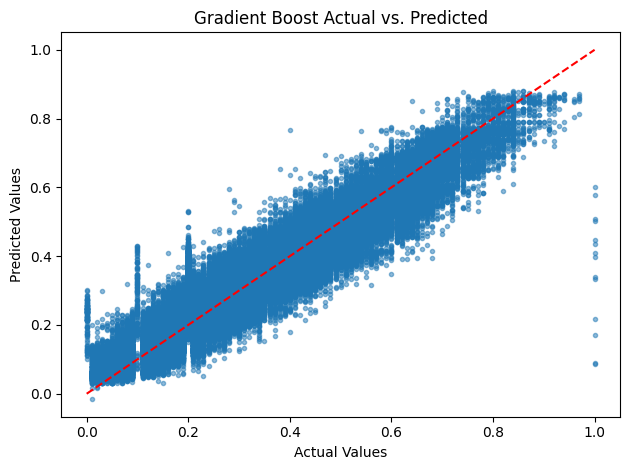

In [ ]:
predictions_gb = boost.predict(X_test)

prediction_scatterplot('Gradient Boost', y_test, predictions_gb)

In [ ]:
boost.feature_importances_*100

array([1.31691781e-04, 9.07488046e+00, 1.50618254e+01, 0.00000000e+00,
       1.83986703e-03, 4.66998401e-03, 0.00000000e+00, 3.85885418e+00,
       0.00000000e+00, 0.00000000e+00, 6.15533613e-01, 2.49648683e+01,
       1.84490051e+00, 1.51458707e+00, 0.00000000e+00, 0.00000000e+00,
       3.91754701e+01, 0.00000000e+00, 3.88243884e+00])

Text(0.5, 0, 'Variable Importance')

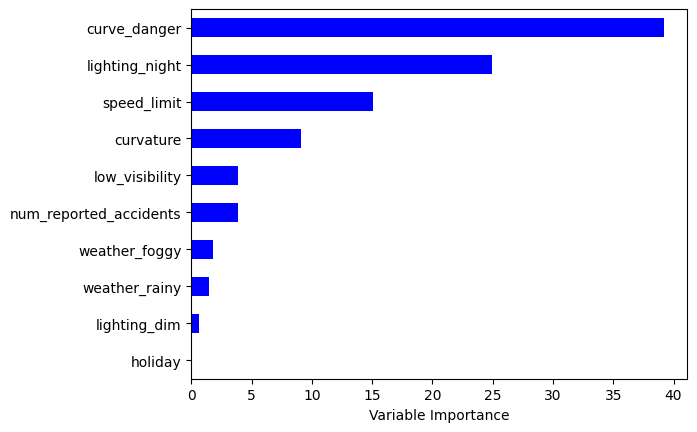

In [ ]:
# Show most important features

feature_importance = boost.feature_importances_*100
rel_imp = pd.Series(feature_importance, index=X_train.columns).sort_values(ascending=False, inplace=False)
rel_imp = rel_imp[0:10]
rel_imp.plot(kind='barh', color='b', ).invert_yaxis()
plt.xlabel('Variable Importance')

In [ ]:
rel_imp.to_csv("top_feature_importances.csv", header=["importance"])
print("CSV file saved as top_feature_importances.csv")

CSV file saved as top_feature_importances.csv


## Neural Network

In [ ]:
model = keras.Sequential([
    # Input Layer & First Hidden Layer
    # input_shape must match the number of features in X_train
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(64, activation='relu'),

    # Second Hidden Layer
    layers.Dense(32, activation='relu'),

    # Output Layer
    # Critical: 'sigmoid' ensures the output is always between 0 and 1
    layers.Dense(1, activation='sigmoid')
])

# 3. Compile the Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',  # Appropriate for continuous regression
    metrics=['mae']             # Mean Absolute Error for easy interpretation
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. Train the Model
print("--- Training ---")
start_time_nn = time.time()
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
end_time_nn = time.time()

--- Training ---
Epoch 1/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.0052 - mae: 0.0545 - val_loss: 0.0033 - val_mae: 0.0449
Epoch 2/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.0034 - mae: 0.0452 - val_loss: 0.0033 - val_mae: 0.0449
Epoch 3/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.0033 - mae: 0.0447 - val_loss: 0.0033 - val_mae: 0.0444
Epoch 4/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.0033 - mae: 0.0447 - val_loss: 0.0032 - val_mae: 0.0445
Epoch 5/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.0033 - mae: 0.0444 - val_loss: 0.0033 - val_mae: 0.0449
Epoch 6/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.0033 - mae: 0.0444 - val_loss: 0.0032 - val_mae: 0.0442
Epoch 7/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.0032 - mae: 0.0444 - val_loss: 0.0032 - val_mae: 0.0444
Epoch 8/20
10356/10356 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.0032 - mae: 0.0444 - val_loss: 0.0032 - val_mae: 0.0442

In [ ]:
print("\n--- Evaluation ---")
print(f"\nTraining Time: {end_time_nn - start_time_nn:.2f} seconds\n")

test_loss, test_mae = model.evaluate(X_test, y_test)

print(f"\nTest MSE (Loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make Predictions
predictions_nn = model.predict(X_test)
# Print first 5 predictions vs actuals
print("\nFirst 5 Predictions vs Actuals:")
for i in range(5):
    print(f"Pred: {predictions_nn[i][0]:.4f} | Actual: {y_test.iloc[i]:.4f}")


--- Evaluation ---

Training Time: 479.45 seconds

3236/3236 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0032 - mae: 0.0442

Test MSE (Loss): 0.0032
Test MAE: 0.0443
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 3s 872us/step

First 5 Predictions vs Actuals:
Pred: 0.1210 | Actual: 0.1500
Pred: 0.3273 | Actual: 0.2000
Pred: 0.2582 | Actual: 0.2900
Pred: 0.2944 | Actual: 0.2500
Pred: 0.3178 | Actual: 0.3200


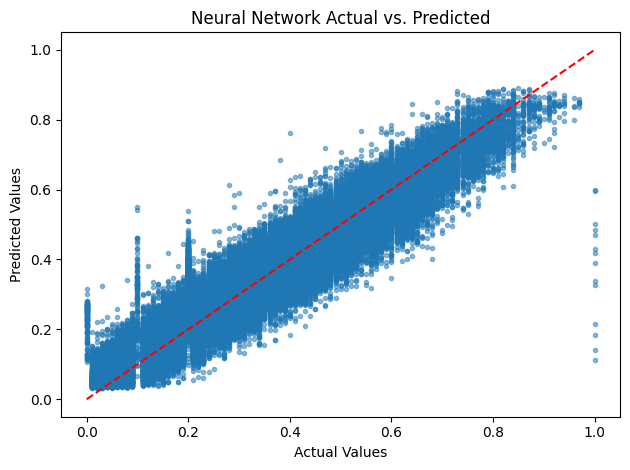

In [ ]:
prediction_scatterplot('Neural Network', y_test, predictions_nn)

In [ ]:
# Calculate R2 using sklearn
r2_nn = r2_score(y_test, predictions_nn)

print(f"Test R2 Score: {r2_nn:.4f}")

Test R2 Score: 0.8823


Model Comparison Table:


,Model,R2 Score,RMSE
0,Baseline (OLS),0.805069,0.073474
1,Random Forest,0.885637,0.056278
2,Gradient Boosting,0.882112,0.057138
3,Neural Network,0.882335,0.057000


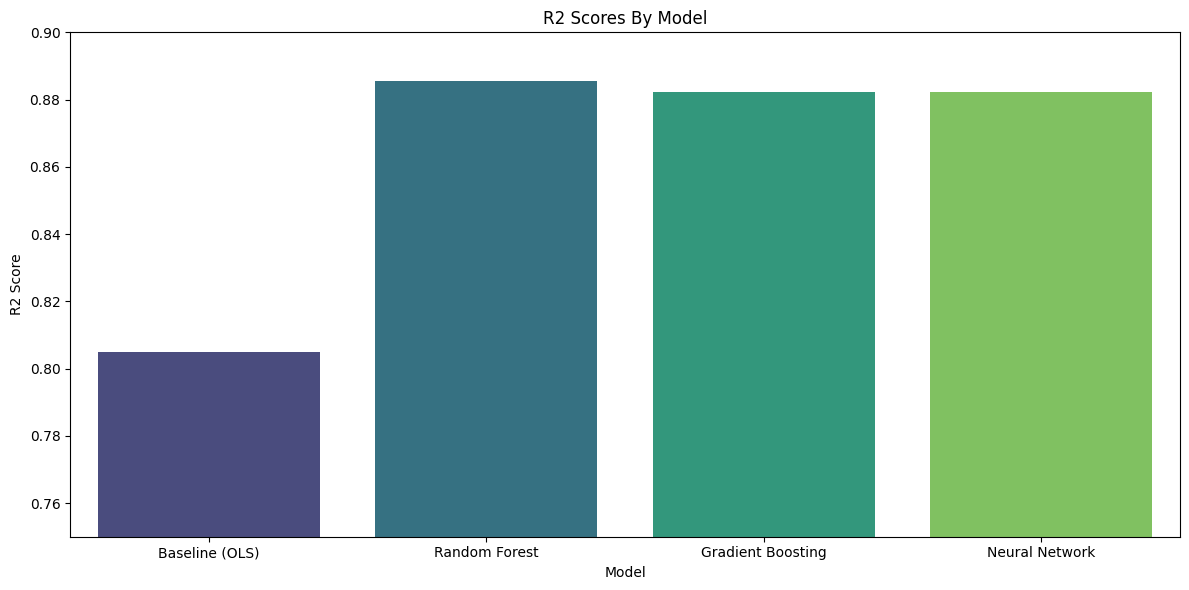

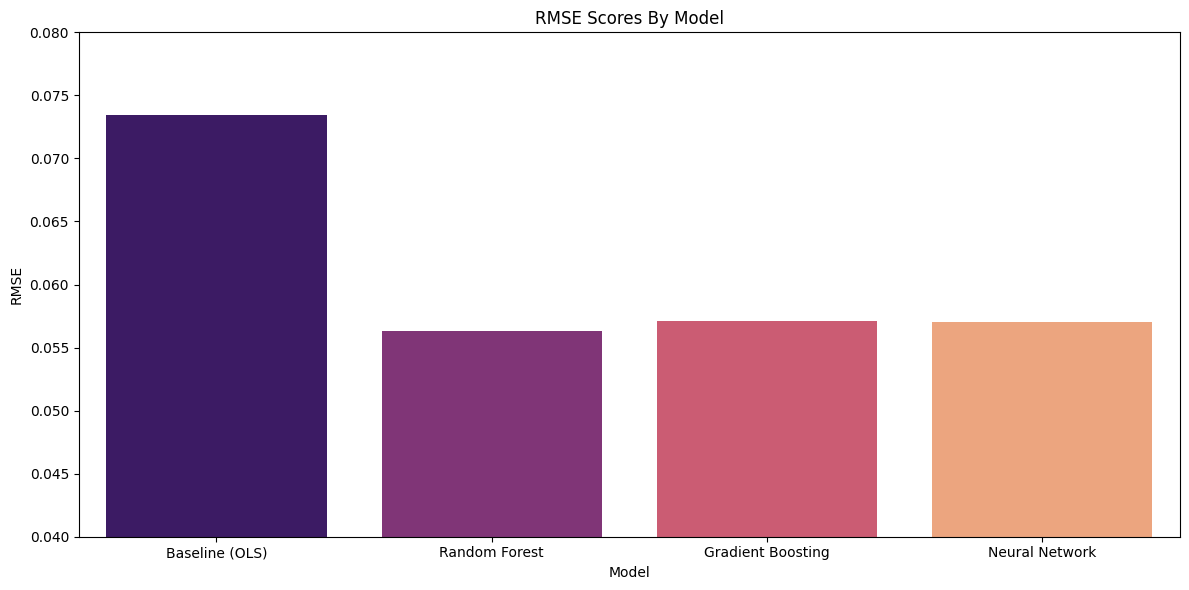

In [ ]:
rmse_nn = np.sqrt(test_loss)

r2_scores_dict = {
    'Baseline (OLS)': r2_scores_ols.mean(),
    'Random Forest': r2_scores_rf.mean(),
    'Gradient Boosting': avg_r2_gb,
    'Neural Network': r2_nn
}

rmse_scores_dict = {
    'Baseline (OLS)': rmse_scores_ols.mean(),
    'Random Forest': rmse_scores_rf.mean(),
    'Gradient Boosting': avg_rmse_gb,
    'Neural Network': rmse_nn
}

comparison_df = pd.DataFrame({
    'Model': list(r2_scores_dict.keys()),
    'R2 Score': list(r2_scores_dict.values()),
    'RMSE': list(rmse_scores_dict.values())
})

print("Model Comparison Table:")
display(comparison_df)

# Plot R2 Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2 Score', data=comparison_df, palette='viridis', hue='Model', legend=False)
plt.title('R2 Scores By Model')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0.75, 0.9)
plt.tight_layout()
plt.show()

# Plot RMSE Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='RMSE', data=comparison_df, palette='magma', hue='Model', legend=False)
plt.title('RMSE Scores By Model')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.ylim(0.04, 0.08)
plt.tight_layout()
plt.show()

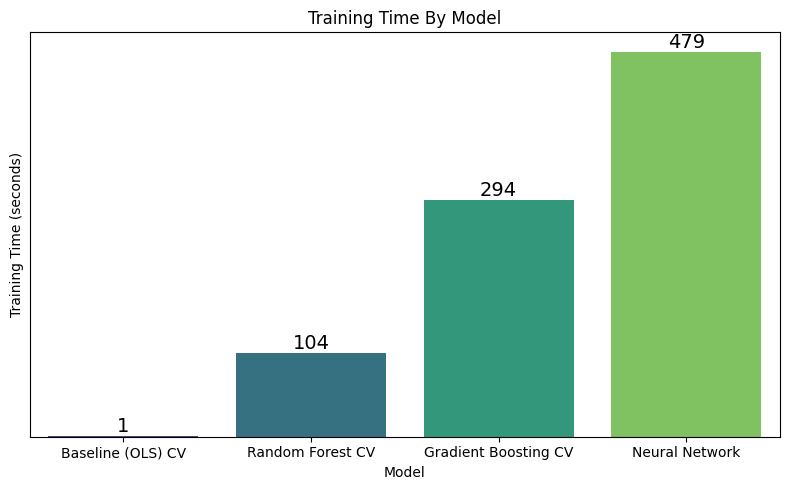

In [ ]:
training_times = {
    'Baseline (OLS) CV': sum(ols_results['fit_time']),
    'Random Forest CV': sum(results['fit_time']),
    'Gradient Boosting CV': sum(scores_gb['fit_time']),
    'Neural Network': end_time_nn - start_time_nn
}

training_time_df = pd.DataFrame(list(training_times.items()), columns=['Model', 'Training Time (seconds)'])

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='Training Time (seconds)', data=training_time_df, palette='viridis', hue='Model', legend=False)
plt.title('Training Time By Model')
plt.xlabel('Model')
ax.set_ylabel('Training Time (seconds)')
ax.set_yticks([])

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=14)

plt.tight_layout()
plt.show()